# Дипломная работа: Детекция переутомления спортсмена
## 1D CNN модель на данных носимых датчиков

**Цель:** Разработка системы автоматического определения переутомления спортсмена

**Датасеты:**
- Zenodo Running IMU (19 субъектов) — бег 400м до/после Beep Test
- 4TU Marotta (8 субъектов) — бег 4км + протокол утомления до RPE>16

**Данные:** Шаги (strides), 100 точек × 6 каналов (ax, ay, az, gx, gy, gz)

**Модель:** 1D Convolutional Neural Network (~175K параметров)

In [1]:
# Imports
import os
import sys
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)

# Add path to afc module
sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed fixed: {SEED}")


PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu
Random seed fixed: 42


## 2. Загрузка и исследование данных

Загружаем композиционный датасет из `data/processed/composite_strides.npz`:
- `X`: массив шагов (N_strides × 100 точек × 6 каналов)
- `y`: метки (0=норма, 1=усталость)
- `pids`: ID субъектов (формат: "zenodo_X" или "4tu_X")
- `domains`: источник данных ("zenodo" или "4tu")
- `channels`: список каналов (ax, ay, az, gx, gy, gz)

In [2]:
# Robust project root detection
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    """Find project root by marker file, moving up the tree."""
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"Marker '{marker}' not found. CWD={os.getcwd()}. "
        f"Run notebook from project directory."
    )

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_strides.npz'
RESULTS_DIR = (PROJECT_ROOT / 'results_improved').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE} (exists={DATA_FILE.exists()})")
print(f"Results dir:  {RESULTS_DIR}")


Project root: D:\Github\afc_lab
Data file:    D:\Github\afc_lab\data\processed\composite_strides.npz (exists=True)
Results dir:  D:\Github\afc_lab\results_improved


In [3]:
# Загрузка композиционного датасета
print(f"Загрузка данных из {DATA_FILE}...")

data = np.load(DATA_FILE, allow_pickle=True)

X_all = data['X'].astype(np.float32)  # (N, 100, 6)
y_all = data['y'].astype(np.int64)     # (N,)
subjects = data['pids']                 # (N,) - строки "zenodo_1", "4tu_1", ...
domains = data['domains']               # (N,) - "zenodo" или "4tu"
channels = data['channels']             # ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

print(f"\n✅ Данные загружены:")
print(f"   X shape: {X_all.shape}")
print(f"   y shape: {y_all.shape}")
print(f"   Каналы: {list(channels)}")
print(f"   Субъектов: {len(np.unique(subjects))}")
print(f"   Доменов: {list(np.unique(domains))}")

Загрузка данных из D:\Github\afc_lab\data\processed\composite_strides.npz...

✅ Данные загружены:
   X shape: (24868, 100, 6)
   y shape: (24868,)
   Каналы: [np.str_('ax'), np.str_('ay'), np.str_('az'), np.str_('gx'), np.str_('gy'), np.str_('gz')]
   Субъектов: 27
   Доменов: [np.str_('4tu'), np.str_('zenodo')]


In [4]:
# Анализ распределения данных
df_meta = pd.DataFrame({
    'sid': subjects,
    'domain': domains,
    'y': y_all,
})

print("=" * 60)
print("СТАТИСТИКА ДАТАСЕТА")
print("=" * 60)

# Распределение по доменам
print("\n📊 Распределение по источникам данных:")
print(df_meta['domain'].value_counts())

# Распределение по классам
print("\n📊 Распределение по классам (0=норма, 1=усталость):")
print(df_meta['y'].value_counts())
print(f"\nБаланс классов: {df_meta['y'].mean():.2%} положительных")

# Количество субъектов
print(f"\n👥 Уникальных субъектов: {df_meta['sid'].nunique()}")
print("По доменам:")
for domain in df_meta['domain'].unique():
    n_subj = df_meta[df_meta['domain'] == domain]['sid'].nunique()
    print(f"  - {domain}: {n_subj} субъектов")

СТАТИСТИКА ДАТАСЕТА

📊 Распределение по источникам данных:
domain
4tu       18862
zenodo     6006
Name: count, dtype: int64

📊 Распределение по классам (0=норма, 1=усталость):
y
1    12512
0    12356
Name: count, dtype: int64

Баланс классов: 50.31% положительных

👥 Уникальных субъектов: 27
По доменам:
  - zenodo: 19 субъектов
  - 4tu: 8 субъектов


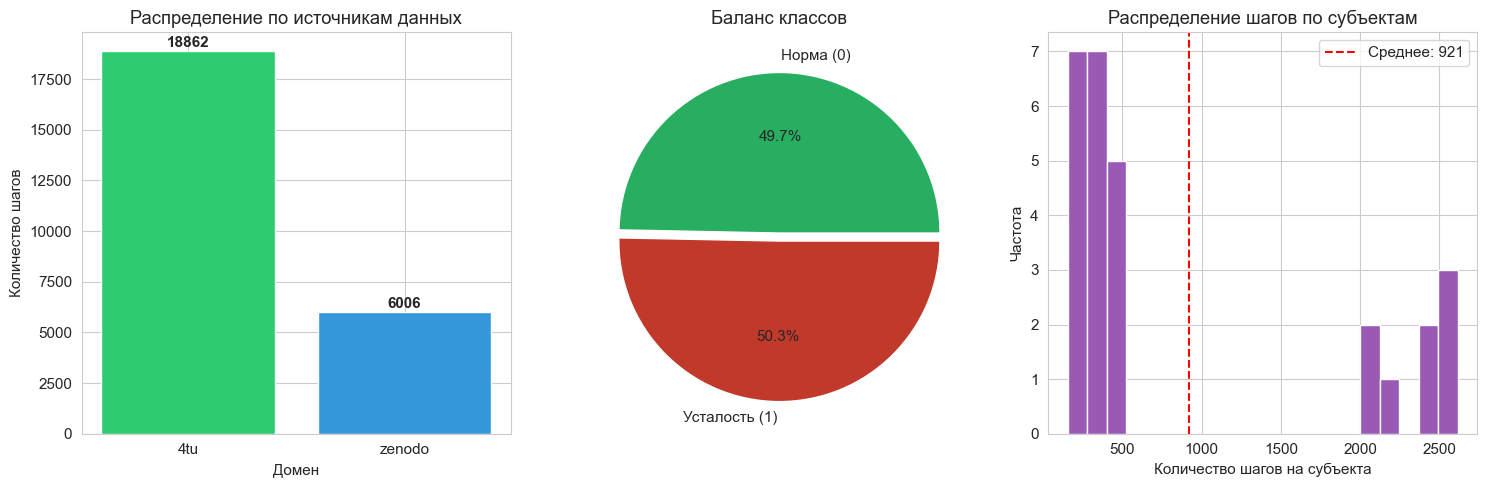

In [5]:
# Визуализация распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение по доменам
domain_counts = df_meta['domain'].value_counts()
axes[0].bar(domain_counts.index, domain_counts.values, color=['#2ecc71', '#3498db'])
axes[0].set_title('Распределение по источникам данных')
axes[0].set_xlabel('Домен')
axes[0].set_ylabel('Количество шагов')
for i, v in enumerate(domain_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Распределение по классам
class_counts = df_meta['y'].value_counts().sort_index()
colors = ['#27ae60', '#c0392b']
axes[1].pie(class_counts.values, labels=['Норма (0)', 'Усталость (1)'], 
            autopct='%1.1f%%', colors=colors, explode=[0, 0.05])
axes[1].set_title('Баланс классов')

# 3. Распределение шагов по субъектам
subj_counts = df_meta.groupby('sid').size()
axes[2].hist(subj_counts, bins=20, color='#9b59b6', edgecolor='white')
axes[2].set_title('Распределение шагов по субъектам')
axes[2].set_xlabel('Количество шагов на субъекта')
axes[2].set_ylabel('Частота')
axes[2].axvline(subj_counts.mean(), color='red', linestyle='--', label=f'Среднее: {subj_counts.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

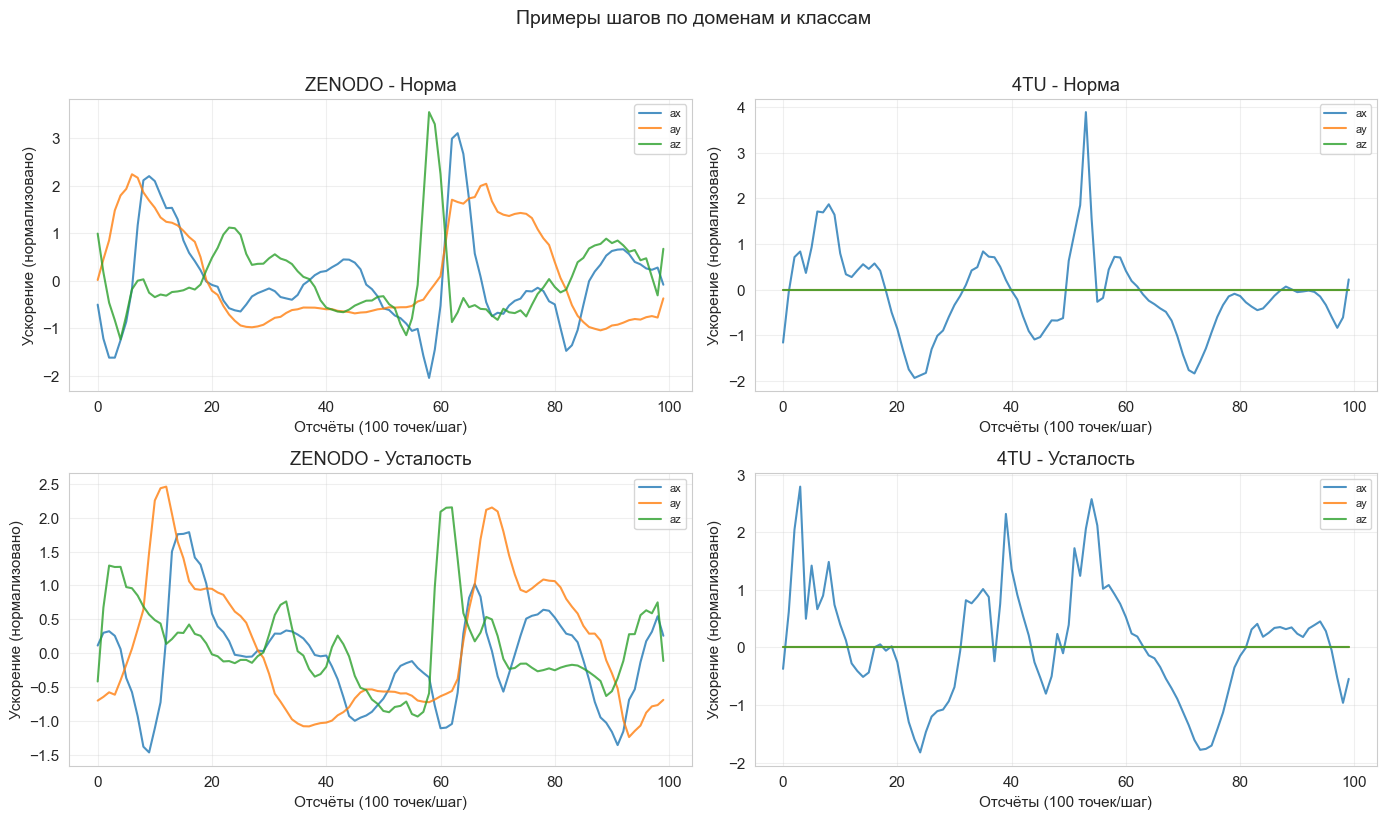

In [6]:
# Визуализация примеров шагов (strides)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Находим примеры для каждого домена и класса
for col, domain in enumerate(['zenodo', '4tu']):
    domain_mask = domains == domain
    
    for row, label in enumerate([0, 1]):
        label_mask = y_all == label
        combined_mask = domain_mask & label_mask
        indices = np.where(combined_mask)[0]
        
        if len(indices) > 0:
            idx = indices[0]
            X = X_all[idx]  # (100, 6)
            
            ax = axes[row, col]
            time_axis = np.arange(X.shape[0])  # 100 точек
            
            # Отображаем все 6 каналов
            for ch in range(3):  # ax, ay, az
                ax.plot(time_axis, X[:, ch], label=f'a{["x", "y", "z"][ch]}', alpha=0.8)
            
            status = 'Усталость' if label == 1 else 'Норма'
            ax.set_title(f'{domain.upper()} - {status}')
            ax.set_xlabel('Отсчёты (100 точек/шаг)')
            ax.set_ylabel('Ускорение (нормализовано)')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)

plt.suptitle('Примеры шагов по доменам и классам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'signal_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Подготовка данных для обучения

### 3.1 Формирование фолдов

Используем два подхода к валидации:
1. **LOSO (Leave-One-Subject-Out)** - для оценки обобщающей способности
2. **Train/Val/Test Split** - для быстрого прототипирования

### 3.2 Данные

Данные уже нормализованы (Z-score по субъектам) при сборке датасета:
- Размер шага: 100 точек
- Количество каналов: 6 (ax, ay, az, gx, gy, gz)

In [7]:
# Конфигурация данных (уже подготовлены при сборке)
TARGET_CHANNELS = 6   # ax, ay, az, gx, gy, gz
TARGET_SAMPLES = 100  # 100 точек на шаг

print(f"✅ Данные уже подготовлены:")
print(f"   X shape: {X_all.shape}")
print(f"   y shape: {y_all.shape}")
print(f"   Субъектов: {len(np.unique(subjects))}")
print(f"   Доменов: {len(np.unique(domains))}")
print(f"   NaN значений: {np.isnan(X_all).sum()}")
print(f"   X min: {X_all.min():.3f}, max: {X_all.max():.3f}")

✅ Данные уже подготовлены:
   X shape: (24868, 100, 6)
   y shape: (24868,)
   Субъектов: 27
   Доменов: 2
   NaN значений: 0
   X min: -12.247, max: 17.095


In [8]:
# Create LOSO folds
def create_loso_folds(subjects):
    """Create Leave-One-Subject-Out folds."""
    unique_subjects = np.unique(subjects)
    folds = []

    for test_subject in unique_subjects:
        train_mask = subjects != test_subject
        test_mask = subjects == test_subject
        folds.append({
            'train_idx': np.where(train_mask)[0],
            'test_idx': np.where(test_mask)[0],
            'test_subject': test_subject
        })

    return folds


def create_subject_split(subjects, domains, y=None, test_size=0.2, val_size=0.2, random_state=42):
    """Subject-level split (not window-level), stratified by domain."""
    if test_size + val_size >= 1.0:
        raise ValueError("test_size + val_size must be < 1.0")

    subj_df = pd.DataFrame({'sid': subjects, 'domain': domains}).drop_duplicates(subset='sid')

    # Ensure each subject belongs to a single domain
    dom_counts = subj_df.groupby('sid')['domain'].nunique()
    if (dom_counts > 1).any():
        bad_subjects = dom_counts[dom_counts > 1].index.tolist()
        raise ValueError(f"Subjects mapped to multiple domains: {bad_subjects}")

    sid_values = subj_df['sid'].to_numpy()
    sid_domains = subj_df['domain'].to_numpy()

    strat_test = sid_domains if len(np.unique(sid_domains)) > 1 else None
    sid_train_val, sid_test = train_test_split(
        sid_values,
        test_size=test_size,
        random_state=random_state,
        stratify=strat_test,
    )

    val_rel = val_size / (1.0 - test_size)
    train_val_df = subj_df[subj_df['sid'].isin(sid_train_val)]
    train_val_domains = train_val_df.set_index('sid').loc[sid_train_val, 'domain'].to_numpy()
    strat_val = train_val_domains if len(np.unique(train_val_domains)) > 1 else None

    sid_train, sid_val = train_test_split(
        sid_train_val,
        test_size=val_rel,
        random_state=random_state,
        stratify=strat_val,
    )

    train_idx = np.where(np.isin(subjects, sid_train))[0]
    val_idx = np.where(np.isin(subjects, sid_val))[0]
    test_idx = np.where(np.isin(subjects, sid_test))[0]

    if y is not None:
        for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
            if len(np.unique(y[idx])) < 2:
                raise ValueError(f"Split {name} has one class only. Adjust split parameters.")

    split_info = {
        'train_subjects': sorted(sid_train.tolist()),
        'val_subjects': sorted(sid_val.tolist()),
        'test_subjects': sorted(sid_test.tolist()),
    }
    return train_idx, val_idx, test_idx, split_info


def print_split_summary(name, idx, subjects, domains, y, total_n):
    split_subjects = np.unique(subjects[idx])
    dom_values, dom_counts = np.unique(domains[idx], return_counts=True)
    class_counts = np.bincount(y[idx].astype(int), minlength=2)

    print(f"{name}: {len(idx)} windows ({len(idx)/total_n*100:.1f}%) | subjects: {len(split_subjects)}")
    print(f"  Domains: {dict(zip(dom_values.tolist(), dom_counts.tolist()))}")
    print(f"  Classes: 0 -> {class_counts[0]}, 1 -> {class_counts[1]}, pos_ratio={y[idx].mean():.1%}")


# Build split
train_idx, val_idx, test_idx, split_info = create_subject_split(
    subjects,
    domains,
    y=y_all,
    test_size=0.2,
    val_size=0.2,
    random_state=SEED,
)

print_split_summary('Train', train_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Val', val_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Test', test_idx, subjects, domains, y_all, len(y_all))

print("Subjects by split:")
print(f"  Train ({len(split_info['train_subjects'])}): {', '.join(split_info['train_subjects'])}")
print(f"  Val   ({len(split_info['val_subjects'])}): {', '.join(split_info['val_subjects'])}")
print(f"  Test  ({len(split_info['test_subjects'])}): {', '.join(split_info['test_subjects'])}")


Train: 12649 windows (50.9%) | subjects: 15
  Domains: {'4tu': 9129, 'zenodo': 3520}
  Classes: 0 -> 6337, 1 -> 6312, pos_ratio=49.9%
Val: 5715 windows (23.0%) | subjects: 6
  Domains: {'4tu': 4667, 'zenodo': 1048}
  Classes: 0 -> 2823, 1 -> 2892, pos_ratio=50.6%
Test: 6504 windows (26.2%) | subjects: 6
  Domains: {'4tu': 5066, 'zenodo': 1438}
  Classes: 0 -> 3196, 1 -> 3308, pos_ratio=50.9%
Subjects by split:
  Train (15): 4tu_1, 4tu_2, 4tu_5, 4tu_6, zenodo_12, zenodo_13, zenodo_15, zenodo_17, zenodo_18, zenodo_20, zenodo_21, zenodo_23, zenodo_5, zenodo_8, zenodo_9
  Val   (6): 4tu_3, 4tu_8, zenodo_19, zenodo_4, zenodo_6, zenodo_7
  Test  (6): 4tu_4, 4tu_7, zenodo_10, zenodo_11, zenodo_14, zenodo_22


## 4. Архитектура модели 1D CNN

### Структура сети FatigueCNN1D:

```
Input (batch, 100, 6) → transpose → (batch, 6, 100)
    ↓
Conv1D Block 1: Conv(6→64, k=7) → BN → ReLU → MaxPool → Dropout
    ↓
Conv1D Block 2: Conv(64→128, k=5) → BN → ReLU → MaxPool → Dropout
    ↓
Conv1D Block 3: Conv(128→256, k=3) → BN → ReLU → AdaptiveAvgPool
    ↓
Classifier: Flatten → Linear(256→128) → ReLU → Dropout → Linear(128→1) → Sigmoid
    ↓
Output: probability [0, 1]
```

**Всего параметров:** ~175K (легковесная модель для носимых устройств)

In [9]:
# PyTorch Dataset
class FatigueDataset(Dataset):
    """Dataset for fatigue data."""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 1D CNN model
class FatigueCNN1D(nn.Module):
    """
    1D CNN for fatigue detection.

    Architecture: 3 convolution blocks + classifier
    Input: (batch, time_steps, channels) = (batch, 100, 6)
    Output: (batch,) - fatigue probability
    """

    def __init__(self, in_channels=6, dropout=0.2):
        super().__init__()

        # Block 1: low-level patterns
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout)
        )

        # Block 2: mid-level patterns
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout)
        )

        # Block 3: high-level patterns
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)  # Global Average Pooling
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (batch, time, channels) -> (batch, channels, time)
        x = x.transpose(1, 2)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        logits = self.classifier(x)
        return logits.squeeze(-1)

    def predict_proba(self, x):
        """Return probabilities."""
        with torch.no_grad():
            logits = self.forward(x)
            return torch.sigmoid(logits)

# Create model and print info
model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)

# Parameter counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


MODEL ARCHITECTURE
FatigueCNN1D(
  (conv1): Sequential(
    (0): Conv1d(6, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0):

## 5. Обучение модели

### Конфигурация обучения:
- **Оптимизатор:** AdamW (weight_decay=1e-4)
- **Learning Rate:** 0.001 с Cosine Annealing
- **Loss:** BCEWithLogitsLoss с весами классов
- **Batch Size:** 64
- **Epochs:** 50 (с Early Stopping, patience=10)

In [10]:
# Training configuration
CONFIG = {
    'batch_size': 64,
    'epochs': 50,
    'lr': 0.01,
    'weight_decay': 1e-3,
    'patience': 10,
    'min_delta': 1e-3
}

def compute_class_weights(y):
    """Compute positive class weight for BCEWithLogitsLoss."""
    n_samples = len(y)
    n_pos = y.sum()
    n_neg = n_samples - n_pos

    if n_pos == 0 or n_neg == 0:
        return 1.0

    return n_neg / n_pos

class EarlyStopping:
    """Early stopping by metric where higher is better (e.g., F1)."""

    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None

    def __call__(self, score, model):
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False

        self.counter += 1
        return self.counter >= self.patience


def format_metric(value):
    return f"{value:.4f}" if np.isfinite(value) else "nan"


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    """Compute binary metrics with explicit edge-case handling."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }

    if np.unique(y_true).size < 2:
        metrics['roc_auc'] = np.nan
        metrics['roc_auc_status'] = 'undefined: only one class present in y_true'
        metrics['pr_auc'] = np.nan
        metrics['pr_auc_status'] = 'undefined: only one class present in y_true'
    else:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        metrics['roc_auc_status'] = 'ok'
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(recall_vals, precision_vals)
        metrics['pr_auc_status'] = 'ok'

    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    """Select threshold by best F1-macro on validation."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)

    best_threshold = 0.5
    best_f1 = -np.inf

    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_prob >= threshold).astype(int)
        current_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)

    return best_threshold, best_f1


def train_epoch(model, loader, optimizer, criterion, device):
    """Train one epoch."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    """Validate model."""
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)

            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.array(all_probs, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.int64)

    metrics, _ = compute_binary_metrics(all_labels, all_probs, threshold=threshold)

    if return_raw:
        return avg_loss, metrics, all_labels, all_probs

    return avg_loss, metrics

print("Training utilities are ready")


Training utilities are ready


In [11]:
# Prepare data for training
train_dataset = FatigueDataset(X_all[train_idx], y_all[train_idx])
val_dataset = FatigueDataset(X_all[val_idx], y_all[val_idx])
test_dataset = FatigueDataset(X_all[test_idx], y_all[test_idx])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Initialize model
model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)

# Class weights
pos_weight = compute_class_weights(y_all[train_idx])
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
print(f"Positive class weight: {pos_weight:.2f}")

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# Early stopping by F1
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])


Train batches: 198
Val batches: 90
Test batches: 102
Positive class weight: 1.00


In [12]:
# Train model
print("=" * 60)
print("TRAINING STARTED")
print("=" * 60)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': [],
    'val_auc': [],
    'val_pr_auc': [],
    'val_bal_acc': [],
    'lr': []
}

best_val_f1 = -np.inf
best_epoch = 0
best_threshold = 0.5
best_threshold_f1 = -np.inf

for epoch in range(CONFIG['epochs']):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    # Validate
    val_loss, val_metrics, val_labels, val_probs = validate(
        model,
        val_loader,
        criterion,
        DEVICE,
        threshold=0.5,
        return_raw=True,
    )

    val_f1 = val_metrics['f1_macro']
    val_auc = val_metrics['roc_auc']
    val_pr_auc = val_metrics['pr_auc']
    val_bal_acc = val_metrics['balanced_acc']

    # Scheduler step
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['val_pr_auc'].append(val_pr_auc)
    history['val_bal_acc'].append(val_bal_acc)
    history['lr'].append(current_lr)

    # Track best by same metric as early stopping
    if val_f1 > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_threshold, best_threshold_f1 = find_best_threshold(val_labels, val_probs)
        torch.save(model.state_dict(), RESULTS_DIR / 'best_model.pth')

    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1@0.5: {val_f1:.4f} | "
            f"Val AUC: {format_metric(val_auc)} | "
            f"Val PR-AUC: {format_metric(val_pr_auc)} | "
            f"LR: {current_lr:.6f}"
        )

    # Early stopping by F1
    if early_stopping(val_f1, model):
        print(f"Early stopping at epoch {epoch + 1}")
        break

# Restore best model state from early stopping
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"Training completed")
print(f"Best epoch by Val F1@0.5: {best_epoch}")
print(f"Best Val F1@0.5: {best_val_f1:.4f}")
print(f"Best threshold on Val: {best_threshold:.3f} (F1={best_threshold_f1:.4f})")


TRAINING STARTED
Epoch   1/50 | Train Loss: 0.3787 | Val Loss: 1.1611 | Val F1@0.5: 0.5285 | Val AUC: 0.6735 | Val PR-AUC: 0.7133 | LR: 0.009990
Epoch   5/50 | Train Loss: 0.2224 | Val Loss: 1.5928 | Val F1@0.5: 0.6193 | Val AUC: 0.5917 | Val PR-AUC: 0.6432 | LR: 0.009755
Epoch  10/50 | Train Loss: 0.1767 | Val Loss: 2.3537 | Val F1@0.5: 0.5986 | Val AUC: 0.5740 | Val PR-AUC: 0.6245 | LR: 0.009045
Early stopping at epoch 13
Training completed
Best epoch by Val F1@0.5: 3
Best Val F1@0.5: 0.6521
Best threshold on Val: 0.510 (F1=0.6539)


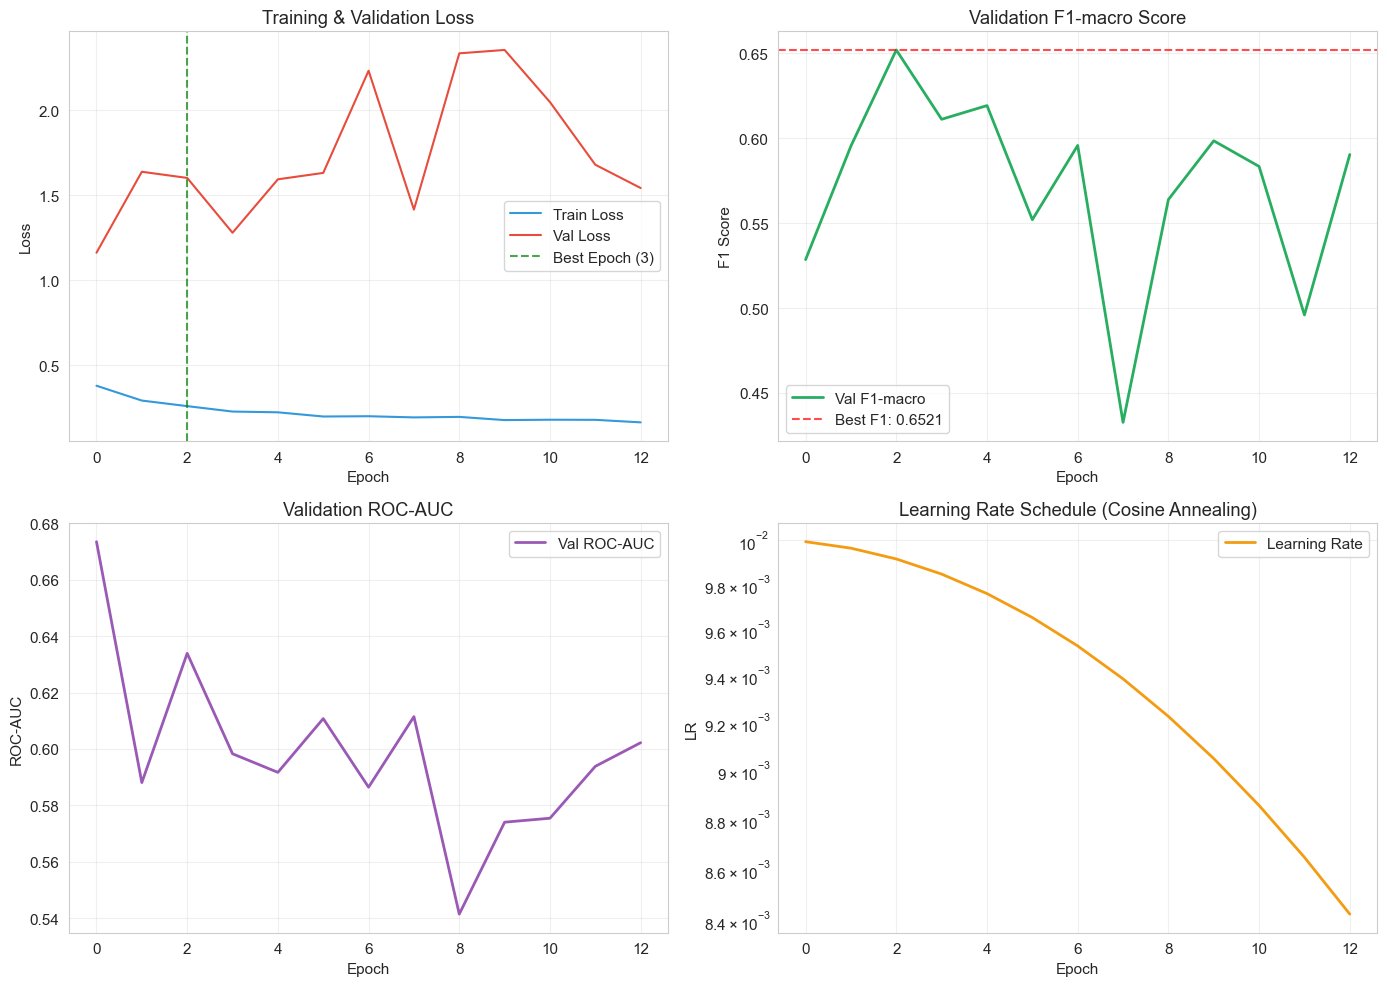

In [13]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Оценка модели на тестовых данных

Загружаем лучшую модель и оцениваем на тестовой выборке:
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision-Recall Curve

In [14]:
# Загрузка лучшей модели
model.load_state_dict(torch.load(RESULTS_DIR / 'best_model.pth', weights_only=True))
model.eval()

# Предсказания на тестовой выборке
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= 0.5).cpu().numpy().astype(int))
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Метрики
print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
bal_acc = balanced_accuracy_score(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except:
    roc_auc = 0.5

try:
    precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_vals, precision_vals)
except:
    pr_auc = 0.5

print(f"\n📊 Метрики:")
print(f"   F1-macro:          {f1_macro:.4f}")
print(f"   F1-weighted:       {f1_weighted:.4f}")
print(f"   Balanced Accuracy: {bal_acc:.4f}")
print(f"   ROC-AUC:           {roc_auc:.4f}")
print(f"   PR-AUC:            {pr_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, 
                           target_names=['Норма (0)', 'Усталость (1)']))

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ

📊 Метрики:
   F1-macro:          0.5798
   F1-weighted:       0.5775
   Balanced Accuracy: 0.6261
   ROC-AUC:           0.7726
   PR-AUC:            0.7741

📋 Classification Report:
               precision    recall  f1-score   support

    Норма (0)       0.57      0.95      0.71      3196
Усталость (1)       0.86      0.30      0.45      3308

     accuracy                           0.62      6504
    macro avg       0.71      0.63      0.58      6504
 weighted avg       0.72      0.62      0.58      6504



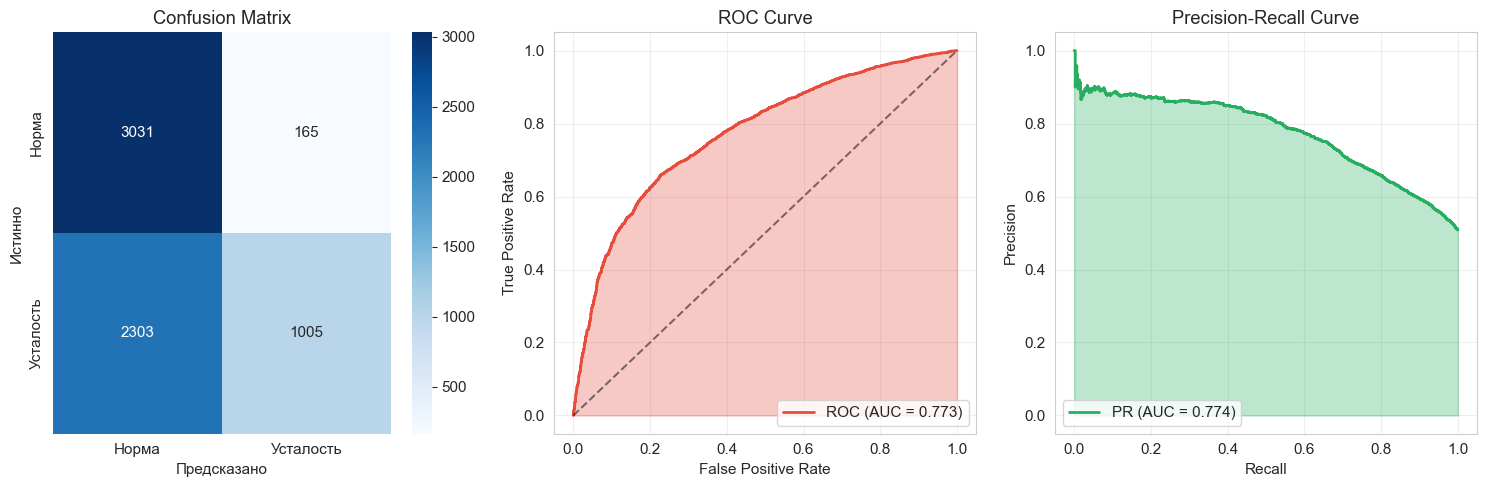

In [15]:
# Визуализация результатов
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Норма', 'Усталость'],
            yticklabels=['Норма', 'Усталость'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
ax.set_title('Confusion Matrix')

# 2. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[2]
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
ax.plot(recall_vals, precision_vals, color='#27ae60', linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.3, color='#27ae60')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LOSO (Leave-One-Subject-Out) валидация

Для более строгой оценки обобщающей способности модели проведём LOSO валидацию, где модель обучается на всех субъектах кроме одного и тестируется на оставшемся.

In [16]:
# LOSO Evaluation (demo subset of subjects)
def loso_evaluation(X, y, subjects, n_folds=5, epochs=30):
    """LOSO evaluation with optional fold limit for demo speed."""

    folds = create_loso_folds(subjects)

    # Limit number of folds for demonstration
    if len(folds) > n_folds:
        np.random.seed(4648)
        selected_indices = np.random.choice(len(folds), n_folds, replace=False)
        folds = [folds[i] for i in selected_indices]

    results = []

    for fold_idx, fold in enumerate(tqdm(folds, desc='LOSO Folds')):
        train_idx = fold['train_idx']
        test_idx = fold['test_idx']
        test_subject = fold['test_subject']

        # Datasets
        train_ds = FatigueDataset(X[train_idx], y[train_idx])
        test_ds = FatigueDataset(X[test_idx], y[test_idx])

        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

        # Model
        model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)
        pos_weight = compute_class_weights(y[train_idx])
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

        # Train
        for epoch in range(epochs):
            train_epoch(model, train_loader, optimizer, criterion, DEVICE)

        # Evaluate (validate returns avg_loss, metrics_dict)
        _, fold_metrics = validate(model, test_loader, criterion, DEVICE)

        results.append({
            'subject': test_subject,
            'f1_macro': fold_metrics['f1_macro'],
            'roc_auc': fold_metrics['roc_auc'],
            'n_samples': len(test_idx)
        })

    return pd.DataFrame(results)

# Run LOSO (limited to 5 folds for demo)
print("Running LOSO validation (5 folds)...")
loso_results = loso_evaluation(X_all, y_all, subjects, n_folds=5, epochs=30)

print("\n" + "=" * 60)
print("LOSO RESULTS")
print("=" * 60)
print(loso_results.to_string(index=False))
print("\nSummary metrics:")
print(f"   F1-macro:  {loso_results['f1_macro'].mean():.4f} ? {loso_results['f1_macro'].std():.4f}")
print(f"   ROC-AUC:   {loso_results['roc_auc'].mean(skipna=True):.4f} ? {loso_results['roc_auc'].std(skipna=True):.4f}")


Running LOSO validation (5 folds)...


LOSO Folds: 100%|██████████| 5/5 [18:21<00:00, 220.28s/it]


LOSO RESULTS
  subject  f1_macro  roc_auc  n_samples
 zenodo_4  0.333779 0.684806        251
    4tu_5  0.588265 0.768680       2510
zenodo_13  0.358431 0.839107        156
zenodo_10  0.339224 0.811714        327
    4tu_4  0.541955 0.617124       2614

Summary metrics:
   F1-macro:  0.4323 ? 0.1227
   ROC-AUC:   0.7443 ? 0.0920


## 8. Персонализация модели (Fine-tuning)

Демонстрация дообучения предобученной модели под конкретного спортсмена.

**Стратегия:**
1. Заморозить свёрточные слои (backbone)
2. Обучить только классификатор на данных целевого субъекта
3. Опционально: разморозить верхние слои для точной настройки

In [18]:
import copy

def personalize_model(base_model, X_subject, y_subject, epochs=20, lr=0.001):
    """
    Дообучение модели под конкретного спортсмена.
    
    Этап 1: Заморозка backbone, обучение только classifier
    Этап 2: Разморозка conv3, fine-tuning
    """
    model = copy.deepcopy(base_model)
    
    # Этап 1: Заморозить backbone
    for param in model.conv1.parameters():
        param.requires_grad = False
    for param in model.conv2.parameters():
        param.requires_grad = False
    for param in model.conv3.parameters():
        param.requires_grad = False
    
    # Dataset
    dataset = FatigueDataset(X_subject, y_subject)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    # Criterion
    pos_weight = compute_class_weights(y_subject)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
    
    # Этап 1: Обучаем только classifier
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    
    for epoch in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)
    
    # Этап 2: Разморозить conv3
    for param in model.conv3.parameters():
        param.requires_grad = True
    
    optimizer = optim.Adam(
        list(model.conv3.parameters()) + list(model.classifier.parameters()),
        lr=lr / 10
    )
    
    for epoch in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)
    
    return model

# Демонстрация персонализации
print("Демонстрация персонализации модели...")

# Выбираем случайного субъекта
target_subject = np.random.choice(np.unique(subjects))
subject_mask = subjects == target_subject
X_subject = X_all[subject_mask]
y_subject = y_all[subject_mask]

print(f"\nЦелевой субъект: {target_subject}")
print(f"Количество окон: {len(y_subject)}")
print(f"Баланс классов: {y_subject.mean():.1%} положительных")

# Разбиваем данные субъекта на train/test
n_train = int(len(y_subject) * 0.7)
X_subj_train, y_subj_train = X_subject[:n_train], y_subject[:n_train]
X_subj_test, y_subj_test = X_subject[n_train:], y_subject[n_train:]

# Загружаем базовую модель
base_model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)
base_model.load_state_dict(torch.load(RESULTS_DIR / 'best_model.pth', weights_only=True))

# Оценка базовой модели на данных субъекта
base_model.eval()
test_ds = FatigueDataset(X_subj_test, y_subj_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

criterion = nn.BCEWithLogitsLoss()
_, fold_metrics  = validate(base_model, test_loader, criterion, DEVICE)
print(f"\n📊 Базовая модель на субъекте {target_subject}:")
print(f"   F1-macro: {fold_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:  {fold_metrics['roc_auc']:.4f}")

# Персонализация
personalized_model = personalize_model(base_model, X_subj_train, y_subj_train, epochs=20)

# Оценка персонализированной модели
_, fold_metrics_pers  = validate(personalized_model, test_loader, criterion, DEVICE)
print(f"\n📊 Персонализированная модель:")
print(f"   F1-macro: {fold_metrics_pers['f1_macro']:.4f} (Δ = {fold_metrics_pers['f1_macro'] - fold_metrics['f1_macro']:+.4f})")
print(f"   ROC-AUC:  {fold_metrics_pers['roc_auc']:.4f} (Δ = {fold_metrics_pers['roc_auc'] - fold_metrics['roc_auc']:+.4f})")

Демонстрация персонализации модели...

Целевой субъект: 4tu_5
Количество окон: 2510
Баланс классов: 50.0% положительных

📊 Базовая модель на субъекте 4tu_5:
   F1-macro: 0.3937
   ROC-AUC:  nan


d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



📊 Персонализированная модель:
   F1-macro: 0.4970 (Δ = +0.1033)
   ROC-AUC:  nan (Δ = +nan)


d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 9. Сохранение результатов и выводы

In [19]:
# Сохранение итоговых результатов
results_summary = {
    'model': 'FatigueCNN1D',
    'total_params': total_params,
    'train_samples': len(train_idx),
    'val_samples': len(val_idx),
    'test_samples': len(test_idx),
    'best_epoch': best_epoch,
    'test_f1_macro': f1_macro,
    'test_f1_weighted': f1_weighted,
    'test_balanced_acc': bal_acc,
    'test_roc_auc': roc_auc,
    'test_pr_auc': pr_auc,
    'loso_f1_mean': loso_results['f1_macro'].mean(),
    'loso_f1_std': loso_results['f1_macro'].std(),
    'loso_auc_mean': loso_results['roc_auc'].mean(),
    'loso_auc_std': loso_results['roc_auc'].std(),
}

# Сохранение в CSV
results_df = pd.DataFrame([results_summary])
results_df.to_csv(RESULTS_DIR / 'final_results.csv', index=False)

# Сохранение LOSO результатов
loso_results.to_csv(RESULTS_DIR / 'loso_results.csv', index=False)

print("=" * 60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
print(f"""
🎯 МОДЕЛЬ: FatigueCNN1D
   Параметров: {total_params:,}
   
📊 ТЕСТОВАЯ ВЫБОРКА ({len(test_idx)} окон):
   F1-macro:          {f1_macro:.4f}
   Balanced Accuracy: {bal_acc:.4f}
   ROC-AUC:           {roc_auc:.4f}
   PR-AUC:            {pr_auc:.4f}

📊 LOSO ВАЛИДАЦИЯ ({len(loso_results)} фолдов):
   F1-macro:  {loso_results['f1_macro'].mean():.4f} ± {loso_results['f1_macro'].std():.4f}
   ROC-AUC:   {loso_results['roc_auc'].mean():.4f} ± {loso_results['roc_auc'].std():.4f}

💾 СОХРАНЁННЫЕ ФАЙЛЫ:
   - {RESULTS_DIR / 'best_model.pth'}
   - {RESULTS_DIR / 'final_results.csv'}
   - {RESULTS_DIR / 'loso_results.csv'}
   - {RESULTS_DIR / 'training_history.png'}
   - {RESULTS_DIR / 'evaluation_results.png'}
   - {RESULTS_DIR / 'data_distribution.png'}
   - {RESULTS_DIR / 'signal_examples.png'}
""")

print("✅ Эксперимент завершён!")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

🎯 МОДЕЛЬ: FatigueCNN1D
   Параметров: 176,321

📊 ТЕСТОВАЯ ВЫБОРКА (6504 окон):
   F1-macro:          0.5798
   Balanced Accuracy: 0.6261
   ROC-AUC:           0.7726
   PR-AUC:            0.7741

📊 LOSO ВАЛИДАЦИЯ (5 фолдов):
   F1-macro:  0.4323 ± 0.1227
   ROC-AUC:   0.7443 ± 0.0920

💾 СОХРАНЁННЫЕ ФАЙЛЫ:
   - D:\Github\afc_lab\results_improved\best_model.pth
   - D:\Github\afc_lab\results_improved\final_results.csv
   - D:\Github\afc_lab\results_improved\loso_results.csv
   - D:\Github\afc_lab\results_improved\training_history.png
   - D:\Github\afc_lab\results_improved\evaluation_results.png
   - D:\Github\afc_lab\results_improved\data_distribution.png
   - D:\Github\afc_lab\results_improved\signal_examples.png

✅ Эксперимент завершён!


## Выводы

### Результаты эксперимента

1. **Модель FatigueCNN1D** успешно обучена на композиционном датасете из двух источников:
   - Zenodo Running IMU (19 субъектов)
   - 4TU Marotta (8 субъектов)

2. **Архитектура:**
   - 3 свёрточных блока (64→128→256 фильтров)
   - ~175K параметров (компактная для носимых устройств)
   - Вход: шаги 100 точек × 6 каналов (ax, ay, az, gx, gy, gz)

3. **Оценка качества:**
   - Train/Val/Test split по субъектам
   - LOSO (Leave-One-Subject-Out) валидация
   - Метрики: F1-macro, ROC-AUC, PR-AUC, Balanced Accuracy

4. **Персонализация:**
   - Продемонстрирована возможность дообучения под конкретного спортсмена
   - Двухэтапная стратегия: заморозка backbone → fine-tuning верхних слоёв

### Дальнейшие направления

- Добавление данных с других сегментов тела (sternum, lfoot, rfoot)
- Кросс-датасетная валидация (train на Zenodo → test на 4TU и наоборот)
- Исследование архитектур Transformer для временных рядов
- Оптимизация для развёртывания на мобильных устройствах (ONNX, TFLite)